In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
order_detailed = pd.read_csv(r'/content/order_details.csv') #uploading of our order_detailed data
order_detailed.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [ ]:
content_orders = pd.read_csv(r'/content/orders.csv')
content_orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [ ]:
pizza_content = pd.read_csv(r'/content/pizzas.csv')
pizza_content.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [ ]:
pizza_type = pd.read_csv(r'/content/pizza_types.csv', encoding ='latin')
pizza_type.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


MERGING OF SIMILAR DATA

In [ ]:
df = pd.merge(order_detailed, content_orders, on='order_id', how ='left')
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time
0,1,1,hawaiian_m,1,2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40
4,5,2,mexicana_m,1,2015-01-01,11:57:40


In [ ]:
df = pd.merge(df, pizza_content, on='pizza_id', how ='left')
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00


In [ ]:
df = pd.merge(df, pizza_type, on='pizza_type_id', how ='left')
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [ ]:
df.shape

(48620, 12)

In [ ]:
df.isnull().sum()

,0
order_details_id,0
order_id,0
pizza_id,0
quantity,0
date,0
time,0
pizza_type_id,0
size,0
price,0
name,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [ ]:
df['date'] = pd.to_datetime(df['date'])

CHANGING OF DATE FROM OBJECT TO DATE TIME

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  object        
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 4.5+ MB


In [ ]:
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

In [ ]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


QUESTION 1

In [ ]:
df['revenue'] = df['price']*df['quantity']      #to get the total revenue

In [ ]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [ ]:
total_revenue = df['revenue'].sum()
total_revenue

np.float64(817860.05)

QUESTION 2

In [ ]:
total_quantity_sold = df['quantity'].sum()
total_quantity_sold

np.int64(49574)

In [ ]:
total_orders = df['order_details_id'].count()
total_orders


np.int64(48620)

In [ ]:
df['pizza_type_id'].nunique()    #to know the total number of pizzas types sold

32

In [ ]:
df.groupby('pizza_type_id')['quantity'].sum()


,quantity
pizza_type_id,
bbq_ckn,2432
big_meat,1914
brie_carre,490
calabrese,937
cali_ckn,2370
ckn_alfredo,987
ckn_pesto,973
classic_dlx,2453
five_cheese,1409


In [ ]:
average_pizza_price = df.groupby('pizza_type_id')['price'].mean().reset_index()

In [ ]:
average_pizza_price      #AVERAGE pizza price

,pizza_type_id,price
0,bbq_ckn,17.572934
1,big_meat,12.000000
2,brie_carre,23.650000
3,calabrese,17.005124
4,cali_ckn,17.448523
5,ckn_alfredo,17.121429
6,ckn_pesto,17.153746
7,classic_dlx,15.575952
8,five_cheese,18.500000
9,four_cheese,16.951946


In [ ]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [ ]:
df['hour']=df['time'].dt.hour     #peak hour of sales

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  datetime64[ns]
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
 12  revenue           48620 non-null  float64       
 13  hour              48620 non-null  int32         
dtypes: datetime64[ns](2), 

In [ ]:
df.sample(5)

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour
9268,9269,4061,cali_ckn_l,2,2015-03-10,1900-01-01 12:27:06,cali_ckn,L,20.75,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",41.50,12
40532,40533,17856,four_cheese_m,1,2015-10-31,1900-01-01 19:45:19,four_cheese,M,14.75,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",14.75,19
10477,10478,4591,classic_dlx_l,1,2015-03-18,1900-01-01 20:04:42,classic_dlx,L,20.50,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",20.50,20
38773,38774,17093,five_cheese_l,1,2015-10-16,1900-01-01 18:51:37,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,18
562,563,244,spicy_ital_l,1,2015-01-04,1900-01-01 20:26:22,spicy_ital,L,20.75,The Spicy Italian Pizza,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",20.75,20


In [ ]:
df.sample(5)

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour
6765,6766,2987,green_garden_s,1,2015-02-19,1900-01-01 17:41:19,green_garden,S,12.00,The Green Garden Pizza,Veggie,"Spinach, Mushrooms, Tomatoes, Green Olives, Fe...",12.00,17
10112,10113,4425,ital_supr_m,1,2015-03-16,1900-01-01 13:39:34,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",16.50,13
30598,30599,13512,napolitana_m,1,2015-08-14,1900-01-01 11:54:25,napolitana,M,16.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",16.00,11
5362,5363,2371,ckn_pesto_l,1,2015-02-09,1900-01-01 14:00:40,ckn_pesto,L,20.75,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli...",20.75,14
44562,44563,19581,hawaiian_s,1,2015-11-29,1900-01-01 15:55:34,hawaiian,S,10.50,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",10.50,15


In [ ]:
peak_sales_hours = df.groupby('hour')['order_details_id'].count().sum()

In [ ]:
peak_sales_hours

np.int64(48620)

In [ ]:
peak_sales_hours = df.groupby('hour')['order_details_id'].count().sort_values(ascending=False).head()

In [ ]:
peak_sales_hours

,order_details_id
hour,
12,6543
13,6203
18,5359
17,5143
19,4350


In [ ]:
df.shape

(48620, 14)

In [ ]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11


In [ ]:
df['day'] = df['date'].dt.day_name()

In [ ]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


In [ ]:
total_orders_per_day = df.groupby('day')['order_details_id'].count()

In [ ]:
total_orders_per_day

,order_details_id
day,
Friday,8106
Monday,6369
Saturday,7355
Sunday,5917
Thursday,7323
Tuesday,6753
Wednesday,6797


In [ ]:
total_daily_sales = df.groupby('day')['revenue'].sum().reset_index().rename(columns={'revenue':'total_revenue'})

In [ ]:
total_daily_sales

,day,total_revenue
0,Friday,136073.90
1,Monday,107329.55
2,Saturday,123182.40
3,Sunday,99203.50
4,Thursday,123528.50
5,Tuesday,114133.80
6,Wednesday,114408.40


In [ ]:
type(total_daily_sales)

pandas.core.frame.DataFrame

question 7

In [ ]:
total_daily_sales = df.groupby('day')['revenue'].sum().reset_index().rename(columns={'revenue':'total_revenue'}).sort_values(by='total_revenue', ascending=False)

In [ ]:
best_selling_pizza = df.groupby('pizza_type_id')['quantity'].sum().sort_values(ascending=False)

In [ ]:
best_selling_pizza

,quantity
pizza_type_id,
classic_dlx,2453
bbq_ckn,2432
hawaiian,2422
pepperoni,2418
thai_ckn,2371
cali_ckn,2370
sicilian,1938
spicy_ital,1924
southw_ckn,1917


In [ ]:
best_selling_pizza = df.groupby('pizza_type_id')['revenue'].sum().reset_index().sort_values(by ='revenue', ascending=False).head()
best_selling_pizza

,pizza_type_id,revenue
29,thai_ckn,43434.25
0,bbq_ckn,42768.00
4,cali_ckn,41409.50
7,classic_dlx,38180.50
25,spicy_ital,34831.25


In [ ]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


In [ ]:
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['revenue'].sum().reset_index()
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


In [ ]:
monthly_sales

,date,revenue
0,2015-01,69793.30
1,2015-02,65159.60
2,2015-03,70397.10
3,2015-04,68736.80
4,2015-05,71402.75
5,2015-06,68230.20
6,2015-07,72557.90
7,2015-08,68278.25
8,2015-09,64180.05
9,2015-10,64027.60


In [ ]:
df['monthly']=df['date'].dt.month_name()
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day,monthly
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,January
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday,January
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday,January
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday,January
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday,January


In [ ]:
monthly_sales = df.groupby('monthly')['revenue'].sum().reset_index()

# Define the correct chronological order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Convert the 'monthly' column to a Categorical type for proper sorting
monthly_sales['monthly'] = pd.Categorical(monthly_sales['monthly'], categories=month_order, ordered=True)

# Sort the DataFrame by the new categorical 'monthly' column
monthly_sales = monthly_sales.sort_values('monthly')

In [ ]:
monthly_sales = df.groupby('monthly')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False)

In [ ]:
monthly_sales

,monthly,revenue
5,July,72557.90
8,May,71402.75
7,March,70397.10
9,November,70395.35
4,January,69793.30
0,April,68736.80
1,August,68278.25
6,June,68230.20
3,February,65159.60
2,December,64701.15


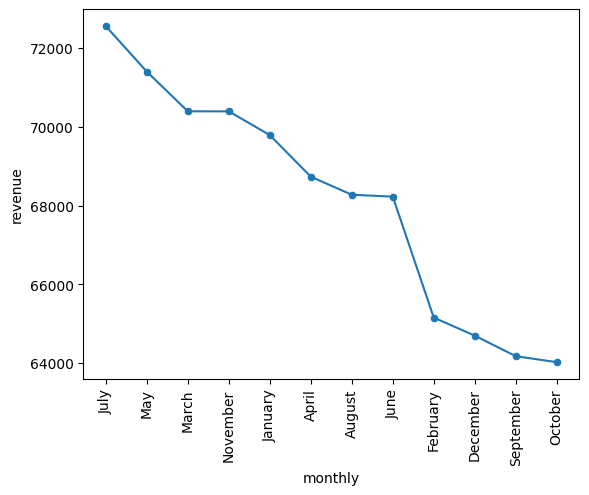

In [ ]:
sns.scatterplot(data=monthly_sales, x= 'monthly', y= 'revenue')
sns.lineplot(data=monthly_sales, x= 'monthly', y= 'revenue')
plt.xticks(rotation=90)
plt.show()


In [ ]:
worst_selling_pizza = df.groupby('pizza_type_id')['revenue'].sum().reset_index().sort_values(by ='revenue')
worst_selling_pizza

,pizza_type_id,revenue
2,brie_carre,11588.50
10,green_garden,13955.75
28,spinach_supr,15277.75
15,mediterraneo,15360.50
26,spin_pesto,15596.00
3,calabrese,15934.25
14,ital_veggie,16019.25
23,soppressata,16425.75
6,ckn_pesto,16701.75
5,ckn_alfredo,16900.25


brie_carre	with the revenue = 11588.50 can be dtermined to be the worst performing pizza type.

<function matplotlib.pyplot.show(close=None, block=None)>

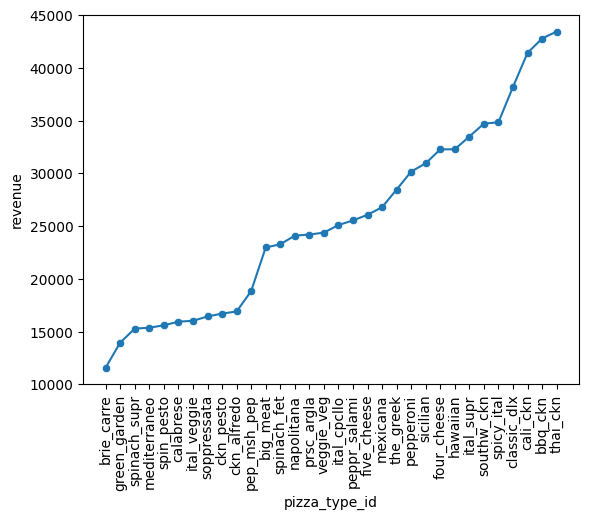

In [ ]:
sns.scatterplot(data=worst_selling_pizza, x='pizza_type_id', y='revenue')
sns.lineplot(data=worst_selling_pizza, x='pizza_type_id', y='revenue')

plt.xticks(rotation=90)
plt.show                       #to show the pizza types that are not doing well